# Gráficas de `inc_data.csv`

Serie temporal del inclinómetro: `yaw`, `pitch`, `roll` (en grados).
Columnas: `date`, `orient`, `dsec`, `yaw`, `pitch`, `roll`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('inc_data2.csv', parse_dates=['date'])
print(f"{len(df)} filas | {df['date'].min()} -> {df['date'].max()}")
df.head()

57650 filas | 2026-07-22 07:35:06 -> 2026-07-22 09:11:18


,date,orient,dsec,yaw,pitch,roll
0,2026-07-22 07:35:06,0,0,-0.43,0.78,-1.28
1,2026-07-22 07:35:06,0,0,-0.43,0.78,-1.28
2,2026-07-22 07:35:06,0,0,-0.43,0.78,-1.29
3,2026-07-22 07:35:06,0,0,-0.43,0.78,-1.29
4,2026-07-22 07:35:06,0,0,-0.43,0.78,-1.29


In [2]:
# Estadísticas rápidas
df[['yaw', 'pitch', 'roll']].describe()

,yaw,pitch,roll
count,57650.000000,57650.000000,57650.000000
mean,0.147203,0.776091,-1.270014
std,0.249582,0.011358,0.010608
min,-0.430000,0.740000,-1.310000
25%,-0.030000,0.770000,-1.280000
50%,0.190000,0.780000,-1.270000
75%,0.340000,0.780000,-1.260000
max,0.520000,0.830000,-1.240000


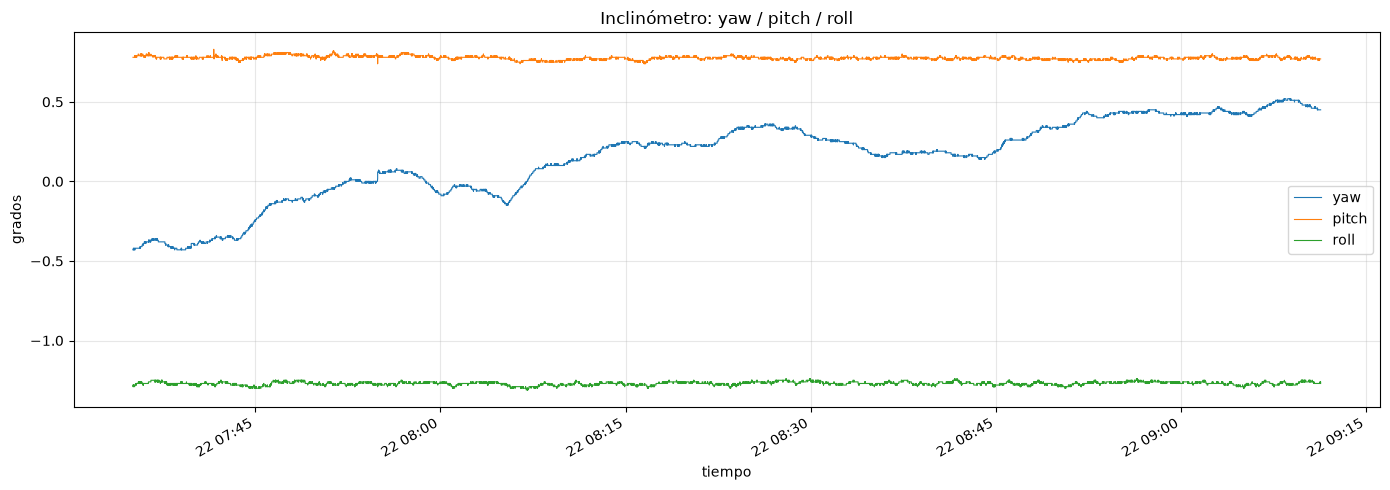

In [3]:
# Las tres señales juntas
fig, ax = plt.subplots(figsize=(14, 5))
for col in ['yaw', 'pitch', 'roll']:
    ax.plot(df['date'], df[col], label=col, linewidth=0.8)
ax.set_xlabel('tiempo')
ax.set_ylabel('grados')
ax.set_title('Inclinómetro: yaw / pitch / roll')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

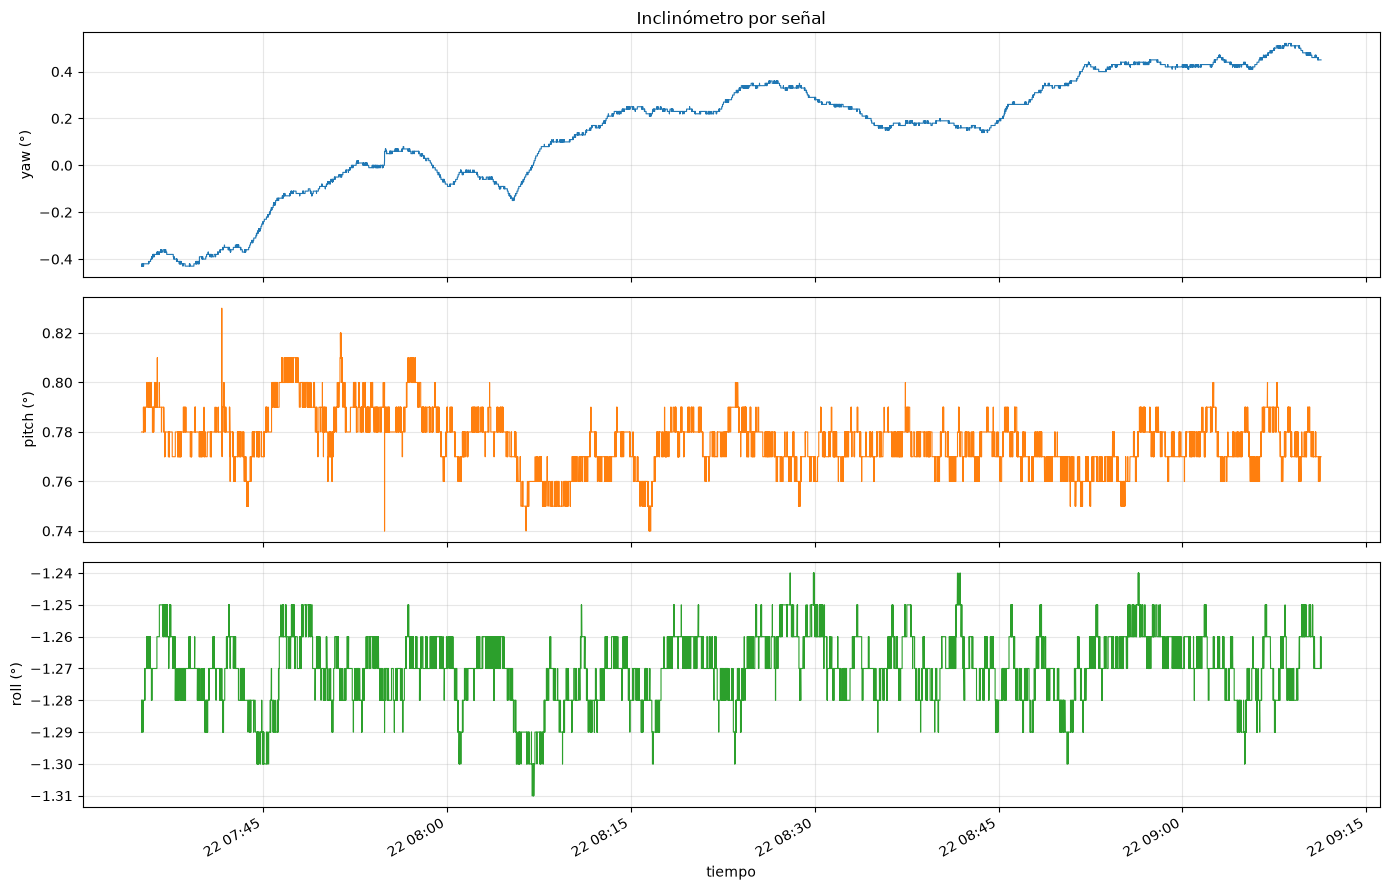

In [4]:
# Subplots separados (cada señal con su propia escala)
cols = ['yaw', 'pitch', 'roll']
colors = ['tab:blue', 'tab:orange', 'tab:green']
fig, axes = plt.subplots(len(cols), 1, figsize=(14, 9), sharex=True)
for ax, col, c in zip(axes, cols, colors):
    ax.plot(df['date'], df[col], color=c, linewidth=0.8)
    ax.set_ylabel(f'{col} (°)')
    ax.grid(True, alpha=0.3)
axes[0].set_title('Inclinómetro por señal')
axes[-1].set_xlabel('tiempo')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

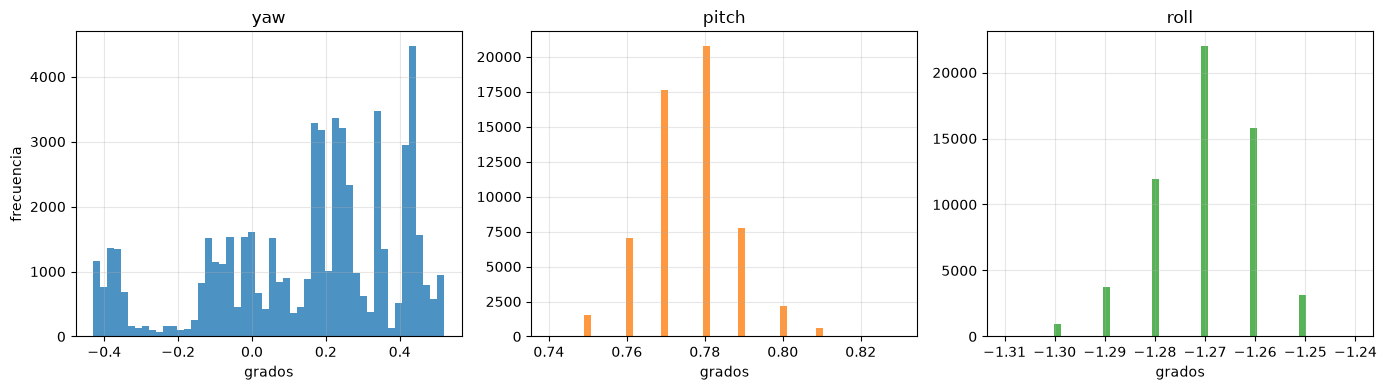

In [5]:
# Distribución de cada señal
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, c in zip(axes, cols, colors):
    ax.hist(df[col], bins=50, color=c, alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('grados')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('frecuencia')
plt.tight_layout()
plt.show()